# Background of Back Propagation

In [50]:
import math
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline

In [51]:
def f(x):
    return 3*x**2 - 4*x + 5

In [52]:
f(3)

20

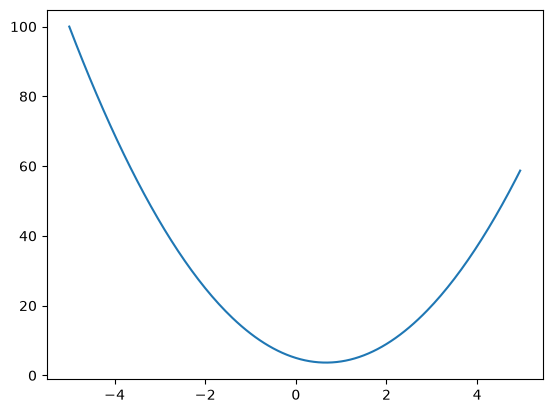

In [53]:
x_values = np.arange(-5, 5, 0.05)
y_values = f(x_values)

plt.plot(x_values, y_values)

In [54]:
h = 0.001
x = 3
(f(x + h) - f(x)) / h

14.00300000000243

In [55]:
class Value:
    def __init__(self, data, _children=(), _op="", label=""):
        self.data = data
        self._prev = set(_children)
        self._op = _op
        self.label = label
        self.grad = 0.0
        self._backward = lambda: None

    def __repr__(self):
        return f"Value = {self.data}"

    def __add__(self, other):
        if not isinstance(other, Value):
            other = Value(other)

        output = Value(self.data + other.data, (self, other), "+")

        def backward():
            self.grad += output.grad
            other.grad += output.grad

        output._backward = backward
        return output

    def __sub__(self, other):
        if not isinstance(other, Value):
            other = Value(other)

        output = Value(self.data - other.data, (self, other), "-")

        def backward():
            self.grad += output.grad
            other.grad -= output.grad

        output._backward = backward
        return output

    def __mul__(self, other):
        if not isinstance(other, Value):
            other = Value(other)

        output = Value(self.data * other.data, (self, other), "*")

        def backward():
            self.grad += output.grad * other.data
            other.grad += output.grad * self.data

        output._backward = backward
        return output

    def __rmul__(self, other):
        return self * other

    def __truediv__(self, other):
        if not isinstance(other, Value):
            other = Value(other)
            
        output = Value(self.data / other.data, (self, other), "/")

        def backward():
            self.grad += output.grad * (1 / other.data)
            other.grad += output.grad * (-self.data / other.data**2)

        output._backward = backward
        return output

    def __pow__(self, other):
        assert isinstance(other, (int, float))

        output = Value(self.data ** other, (self,), "**")

        def backward():
            # d(x^y)/dx = y * x^(y-1)
            self.grad += output.grad * other * (self.data ** (other - 1))

            # d(x^y)/dy = x^y * ln(x)
            # other.grad += output.grad * output.data * math.log(self.data)

        output._backward = backward
        return output

    def do_back_prop(self):
        sorted_nodes: Value = []
        visited = set()
        
        def build_topo(node: Value):
            if node not in visited:
                visited.add(node)
                for child in node._prev:
                    build_topo(child)
                sorted_nodes.append(node)

        build_topo(self)
        
        self.grad = 1.0 # base case
        for node in reversed(sorted_nodes):
            node._backward()

    def tanh(self):
        x = self.data
        numerator = math.exp(2 * x) - 1
        denomitor = math.exp(2 * x) + 1
        output = Value(numerator / denomitor, (self, ), _op="tanh", label="out")

        def backward():
            self.grad += (1 - output.data**2) * output.grad

        output._backward = backward
        return output    

In [56]:
a = Value(3.0, label="a")
b = Value(-4.5, label="b")

c = a + b

c.label = "c"

In [57]:
from graphviz import Digraph

def trace(root):
  # builds a set of all nodes and edges in a graph
  nodes, edges = set(), set()
  def build(v):
    if v not in nodes:
      nodes.add(v)
      for child in v._prev:
        edges.add((child, v))
        build(child)
  build(root)
  return nodes, edges

def draw_dot(root):
  dot = Digraph(format='svg', graph_attr={'rankdir': 'LR'}) # LR = left to right
  
  nodes, edges = trace(root)
  for n in nodes:
    uid = str(id(n))
    # for any value in the graph, create a rectangular ('record') node for it
    dot.node(name = uid, label = "{ %s | data %.4f | grad %.4f }" % (n.label, n.data, n.grad), shape='record')
    if n._op:
      # if this value is a result of some operation, create an op node for it
      dot.node(name = uid + n._op, label = n._op)
      # and connect this node to it
      dot.edge(uid + n._op, uid)

  for n1, n2 in edges:
    # connect n1 to the op node of n2
    dot.edge(str(id(n1)), str(id(n2)) + n2._op)

  return dot

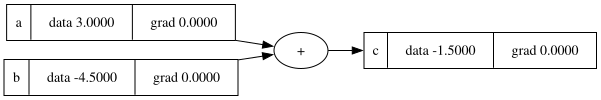

In [58]:
draw_dot(c)

In [59]:
c.grad = 1.0
c._backward()

In [60]:
# inputs
x1 = Value(2.0, label="x1")
x2 = Value(-1.0, label="x2")

# weights and bias
w1 = Value(-3.0, label="w1")
w2 = Value(3.0, label="w2")
b = Value(6.7286, label="b")

# z = x1*w1 + x2*w2 + b
x1w1 = x1 * w1
x1w1.label = "x1w1"
x2w2 = x2 * w2
x2w2.label = "x2w2"

x1w1x2w2 = x1w1 + x2w2
x1w1x2w2.label = "x1w1 + x2w2"

z = x1w1x2w2 + b
z.label = "z"

# applying the tanh activation function (o = z.tanh())
o = z.tanh()
o.label = "o"

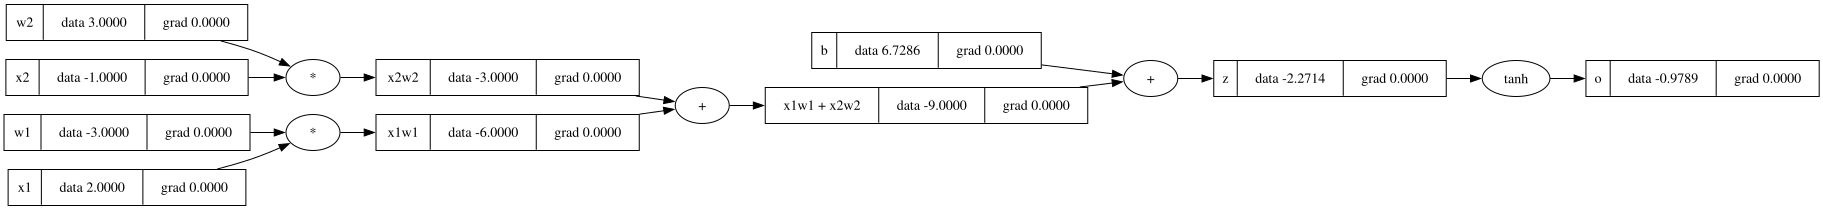

In [61]:
# drawing the ouptut
draw_dot(o)

In [62]:
# calculating derivatives and setting them up

# do/do = 1.0
o.grad = 1.0

# do/dz = 1 - tanh(z)^2 => tanh(z) = o => do/dz = 1 - o^2
z.grad = 1 - o.data**2

# do/db = do/dz * dz/db => dz/db = 1.0
b.grad = z.grad * 1.0

# do/d(x1w1 + x2w2) = do/dz * dz/d(x1w1 + x2w2) => dz/d(x1w1 + x2w2) = 1.0
x1w1x2w2.grad = z.grad * 1.0

# since again we have a '+' distributor, the same logic has above is applied and x1w1x2w2.grad flows backwards to x1w1 and x2w2
x1w1.grad = x1w1x2w2.grad * 1.0
x2w2.grad = x1w1x2w2.grad * 1.0

# do/dx1 = do/d(x1w1) * d(x1w1)/dx1 => d(x1w1)/dx1 = w1
x1.grad = x1w1.grad * w1.data
# similarly
w1.grad = x1w1.grad * x1.data

# do/dx2 = do/d(x2w2) * d(x2w2)/dx2 => d(x2w2)/dx2 = w2
x2.grad = x2w2.grad * w2.data
# similarly
w2.grad = x2w2.grad * x2.data

In [63]:
# automatic back-propagation
o.grad = 1.0 # initialization as a base case
o._backward()

z._backward()

x1w1x2w2._backward()

x1w1._backward()
x2w2._backward()

In [64]:
# applying topological sort to make the graph's edges move from left to right
# this way, we will be able to call ._backward() for every node in a graph

sorted_nodes: Value = []
visited = set()
def build_topo(node: Value):
    if node not in visited:
        visited.add(node)
        for child in node._prev:
            build_topo(child)
        sorted_nodes.append(node)

build_topo(o)
sorted_nodes

[Value = 6.7286,
 Value = 2.0,
 Value = -3.0,
 Value = -6.0,
 Value = -1.0,
 Value = 3.0,
 Value = -3.0,
 Value = -9.0,
 Value = -2.2714,
 Value = -0.9789370591027207]

In [65]:
# and now we call ._backward() on the sorted_nodes one by one so that it applies to every single node
o.grad = 1.0 # base case
for node in reversed(sorted_nodes):
    node._backward()

In [66]:
o.do_back_prop() # final automatic back propagation

# Building an MLP from Scratch

In [67]:
class Neuron:
    def __init__(self, n):
        self.weights = [Value(np.random.uniform(-1, 1)) for _ in range(n)]
        self.bias = Value(np.random.uniform(-1, 1))

    def __call__(self, x):
        # returns w*x + b
        z = sum((wi*xi for wi, xi in zip(self.weights, x)), self.bias)
        out = z.tanh()
        return out

    def parameters(self):
        return self.weights + [self.bias]

In [68]:
class Layer:
    def __init__(self, n_in, n_out):
        self.neurons = [Neuron(n_in) for _ in range(n_out)]

    def __call__(self, x):
        outs = [neuron(x) for neuron in self.neurons]
        return outs

    def parameters(self):
        params = []
        for neuron in self.neurons:
            params.extend(neuron.parameters())

        return params

In [69]:
class MLP:
    def __init__(self, n_in, n_outs):
        self.layers = [Layer(n_in, n_outs[i]) for i in range(len(n_outs))]

    def __call__(self, x):
        for layer in self.layers:
            out = layer(x)
        return out

    def parameters(self):
        return [p for layer in self.layers for p in layer.parameters()]

In [70]:
x = [1.0, 2.0, -3.0]
NN = MLP(3, [4, 4, 1])
forward_pass = NN(x)

len(NN.parameters())

36

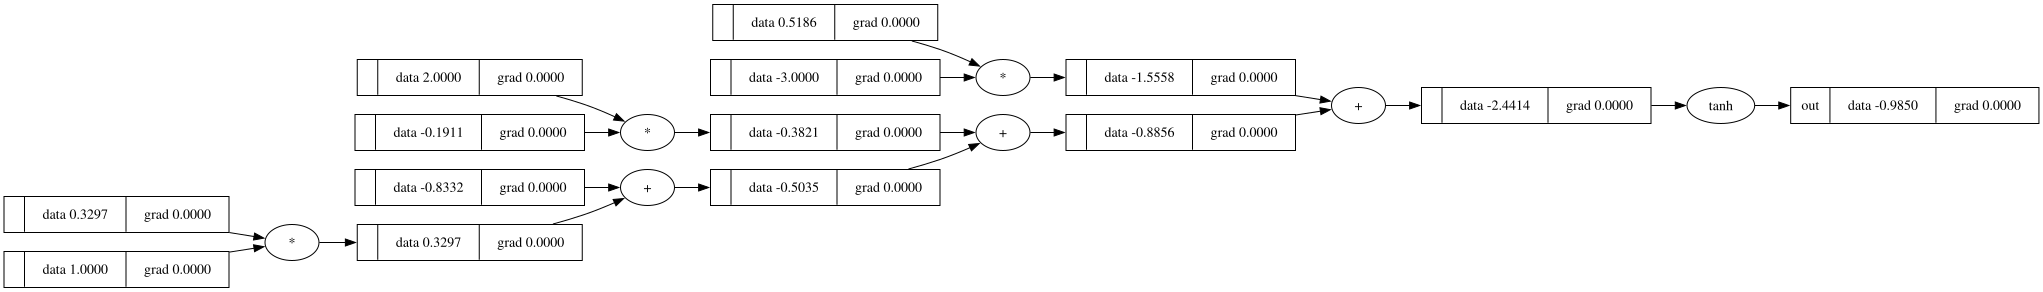

In [71]:
draw_dot(NN(x)[0])

In [ ]:
xs = [
    [2.0, 3.0, -1.0],
    [3.0, -1.0, 0.5],
    [0.5, 1.0, 1.0],
    [1.0, 1.5, -1.0]
]

ys = [1.0, -1.0, -1.0, 1.0]

[Value = -0.8525856351161768,
 Value = 0.5415388064156387,
 Value = -0.3282006925671771,
 Value = -0.8639429803898333]

In [84]:
ypred = [NN(x)[0] for x in xs]
loss = sum(((y_out - y_gt)**2 for y_gt, y_out in zip(ys, ypred)), Value(0))
print(f"Loss: {loss}")
loss.do_back_prop()
# draw_dot(loss)

Loss: Value = 0.00015252419576894423


In [83]:
for p in NN.parameters():
    p.data += -0.01 * p.grad

In [85]:
ypred

[Value = 0.9999968936757291,
 Value = -1.0,
 Value = -0.9877344463574618,
 Value = 0.9985576477678074]